# Лабораторная работа №1. Ноутбук 1/3 — EDA (пункты 1–4)

- Датасет: [GitHub Issues](https://www.kaggle.com/datasets/davidshinn/github-issues) — заголовки и описания issue с GitHub, 2017 год, ~8 млн строк в оригинале, в данной версии `github_issues.csv` ~6.26 млн строк (2.85 ГБ), колонки `issue_url`, `issue_title`, `body`.

- Целевая текстовая колонка: `body` (полный текст issue) — используется как основной объект анализа во всех трёх ноутбуках. `issue_title` используется только для сравнения длины текстов (см. п.2).

- Работа с объёмом данных: файл слишком большой (2.85 ГБ, ~6.26 млн строк), чтобы гонять по нему N-граммы/Левенштейна/генерацию текста в учебном ноутбуке. Поэтому берётся случайная репрезентативная подвыборка ~50 000 issues через потоковое чтение файла чанками + сэмплирование внутри каждого чанка.


In [1]:
import re
import html as html_mod
import time
from collections import Counter
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from nltk.corpus import stopwords

RAW_PATH = Path("github_issues.csv")
ARTIFACTS_DIR = Path("artifacts")
ARTIFACTS_DIR.mkdir(exist_ok=True)

SAMPLE_SIZE = 50_000
RANDOM_SEED = 42
CHUNK_SIZE = 200_000
SAMPLE_FRAC = 0.012  # даёт запас ~1.3x над SAMPLE_SIZE, финальный размер фиксируем позже

rng = np.random.default_rng(RANDOM_SEED)
ENGLISH_STOPWORDS = set(stopwords.words("english"))


## Шаг 1. Загрузка датасета, выбор целевой колонки, train/test split 80/20

In [2]:
t0 = time.time()
chunks = []
total_rows_seen = 0

for chunk in pd.read_csv(
    RAW_PATH,
    usecols=["issue_title", "body"],
    chunksize=CHUNK_SIZE,
):
    total_rows_seen += len(chunk)
    sampled = chunk.sample(frac=SAMPLE_FRAC, random_state=RANDOM_SEED)
    chunks.append(sampled)

df_sample = pd.concat(chunks, ignore_index=True)
print(f"Прочитано строк из файла: {total_rows_seen:,}")
print(f"Собрано в предварительную подвыборку: {len(df_sample):,}")
print(f"Время чтения всего файла чанками: {time.time() - t0:.1f} сек")


Прочитано строк из файла: 5,332,153
Собрано в предварительную подвыборку: 63,986
Время чтения всего файла чанками: 25.8 сек


### отбрасываем документы с пустым телом issue - для них нет целевого текста для анализа

In [3]:
before = len(df_sample)
df_sample = df_sample.dropna(subset=["body"]).reset_index(drop=True)
df_sample = df_sample[df_sample["body"].str.strip().str.len() > 0].reset_index(drop=True)
print(f"Удалено документов с пустым body: {before - len(df_sample)}")

df_sample = df_sample.sample(n=SAMPLE_SIZE, random_state=RANDOM_SEED).reset_index(drop=True)
print(f"Итоговый размер подвыборки: {len(df_sample):,} документов")
df_sample.head(3)


Удалено документов с пустым body: 0
Итоговый размер подвыборки: 50,000 документов


,issue_title,body
0,suggestion: automation/triggers on pages,"hello, i think it would be great if we have au..."
1,http://rusi.ca doesn't redirect to https://rus...,"hi james, ref our telecon. when i use http://r..."
2,nodelist and other arrays ?,"first of all, thanks for this tool! hopefully ..."


**Про стратификацию:** в датасете только сырой текст, поэтому ниже выполняется обычный случайный train/test split 80/20 с фиксированным `random_state`.

In [4]:
n = len(df_sample)
perm = rng.permutation(n)
n_train = int(round(n * 0.8))

train_idx = perm[:n_train]
test_idx = perm[n_train:]

train_df = df_sample.iloc[train_idx].reset_index(drop=True)
test_df = df_sample.iloc[test_idx].reset_index(drop=True)

print(f"Train: {len(train_df):,} ({len(train_df)/n:.1%})")
print(f"Test:  {len(test_df):,} ({len(test_df)/n:.1%})")

# train_df.to_csv(ARTIFACTS_DIR / "train_raw.csv", index=False)
# test_df.to_csv(ARTIFACTS_DIR / "test_raw.csv", index=False)
# print("Сохранено:", ARTIFACTS_DIR / "train_raw.csv", "и", ARTIFACTS_DIR / "test_raw.csv")


Train: 40,000 (80.0%)
Test:  10,000 (20.0%)


## Шаг 2. Структура данных на обучающей выборке

In [5]:
def word_count(s):
    return len(re.findall(r"\w+", s)) if isinstance(s, str) else 0

def char_count(s):
    return len(s) if isinstance(s, str) else 0

train_df["body_words"] = train_df["body"].map(word_count)
train_df["body_chars"] = train_df["body"].map(char_count)
train_df["title_words"] = train_df["issue_title"].map(word_count)
train_df["title_chars"] = train_df["issue_title"].map(char_count)

print(f"Документов в train: {len(train_df):,}")
print()
print("body  (целевая колонка): "
      f"средняя длина = {train_df['body_words'].mean():.1f} слов / {train_df['body_chars'].mean():.1f} символов, "
      f"медиана = {train_df['body_words'].median():.0f} слов / {train_df['body_chars'].median():.0f} символов")
print("title (для сравнения):   "
      f"средняя длина = {train_df['title_words'].mean():.1f} слов / {train_df['title_chars'].mean():.1f} символов, "
      f"медиана = {train_df['title_words'].median():.0f} слов / {train_df['title_chars'].median():.0f} символов")


Документов в train: 40,000

body  (целевая колонка): средняя длина = 70.5 слов / 427.0 символов, медиана = 50 слов / 294 символов
title (для сравнения):   средняя длина = 7.0 слов / 43.4 символов, медиана = 6 слов / 39 символов


Вывод 1: `body` в среднем существенно длиннее `issue_title`

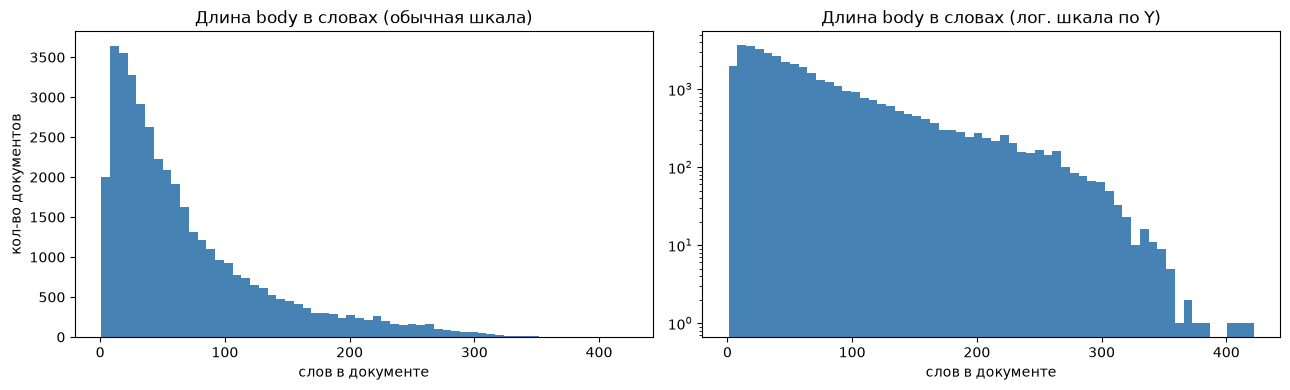

Skewness (асимметрия) длины body в словах: 1.52
Доля документов длиннее 500 слов: 0.00%


In [6]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].hist(train_df["body_words"], bins=60, color="steelblue")
axes[0].set_title("Длина body в словах (обычная шкала)")
axes[0].set_xlabel("слов в документе")
axes[0].set_ylabel("кол-во документов")

axes[1].hist(train_df["body_words"], bins=60, color="steelblue")
axes[1].set_yscale("log")
axes[1].set_title("Длина body в словах (лог. шкала по Y)")
axes[1].set_xlabel("слов в документе")

plt.tight_layout()
plt.show()

print(f"Skewness (асимметрия) длины body в словах: {train_df['body_words'].skew():.2f}")
print(f"Доля документов длиннее 500 слов: {(train_df['body_words'] > 500).mean():.2%}")


Вывод 2: распределение длины текста скошено вправо (heavy-tailed) — большинство issue короткие, но есть немногочисленные очень длинные документы (логи, стектрейсы). Проверяется через коэффициент асимметрии (skewness) и визуально через гистограмму в обычном и логарифмическом масштабе.

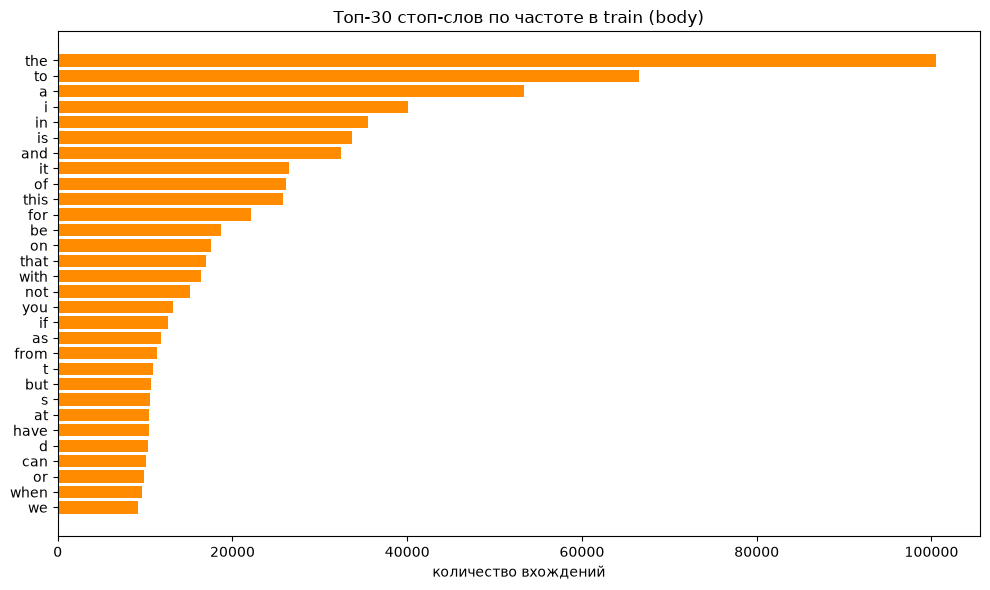

In [7]:
def tokenize_simple(s):
    return re.findall(r"[a-zA-Zа-яА-Я]+", s.lower()) if isinstance(s, str) else []

token_counter = Counter()
for body in train_df["body"]:
    token_counter.update(tokenize_simple(body))

stopword_counts = {w: c for w, c in token_counter.items() if w in ENGLISH_STOPWORDS}
top30_stopwords = Counter(stopword_counts).most_common(30)

fig, ax = plt.subplots(figsize=(10, 6))
words, counts = zip(*top30_stopwords)
ax.barh(words[::-1], counts[::-1], color="darkorange")
ax.set_title("Топ-30 стоп-слов по частоте в train (body)")
ax.set_xlabel("количество вхождений")
plt.tight_layout()
plt.show()


## Шаг 3. Анализ специфического шума домена GitHub Issues

In [7]:
NOISE_PATTERNS = {
    "url (http/https)": r"https?://\S+",
    "html tag <...>": r"<[a-zA-Z!/][^<>]{0,200}>",
    "escaped-slash artefact (&x2f;)": r"&\s?x2f;",
    "@mention": r"@\w+",
    "code fence ```": r"```",
    "inline code `...`": r"`[^`]+`",
    "hex code 0x...": r"\b0x[0-9a-fA-F]+\b",
    "cyrillic": r"[а-яА-ЯёЁ]",
    "cjk": r"[\u4e00-\u9fff]",
    "emoji / misc symbols": r"[\U0001F300-\U0001FAFF]",
}

bodies = train_df["body"].astype(str)
noise_stats = []
for name, pattern in NOISE_PATTERNS.items():
    compiled = re.compile(pattern)
    doc_hits = bodies.str.contains(compiled, regex=True, na=False)
    noise_stats.append({
        "noise_type": name,
        "docs_share": doc_hits.mean(),
        "docs_count": int(doc_hits.sum()),
    })

noise_df = pd.DataFrame(noise_stats).sort_values("docs_share", ascending=False).reset_index(drop=True)
noise_df["docs_share"] = (noise_df["docs_share"] * 100).round(2)
noise_df.columns = ["Тип шума", "% документов", "Кол-во документов"]
noise_df


,Тип шума,% документов,Кол-во документов
0,url (http/https),33.50,13401
1,html tag <...>,10.12,4047
2,@mention,7.94,3175
3,cjk,0.94,376
4,emoji / misc symbols,0.92,366
5,hex code 0x...,0.80,318
6,cyrillic,0.79,315
7,escaped-slash artefact (&x2f;),0.14,57
8,code fence ```,0.00,0
9,inline code `...`,0.00,0


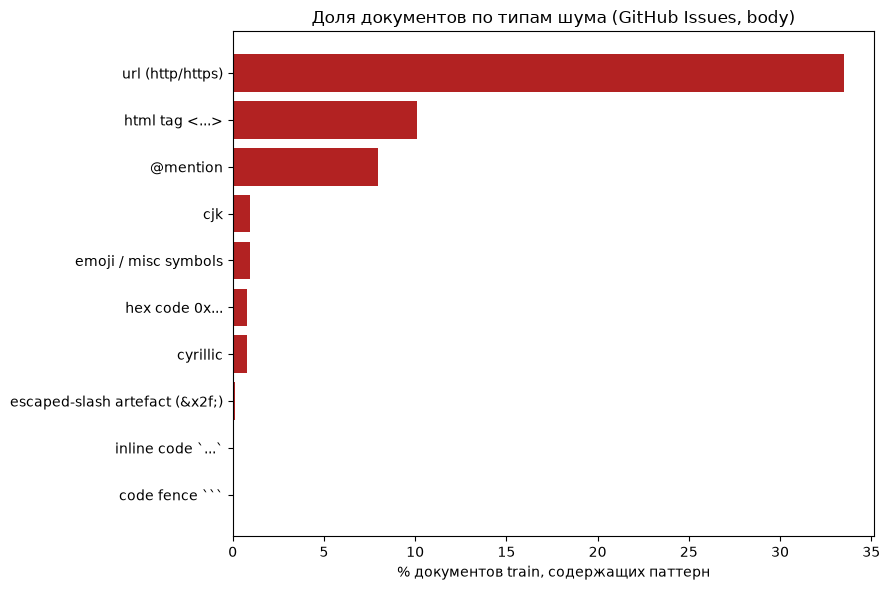

In [8]:
fig, ax = plt.subplots(figsize=(9, 6))
plot_df = noise_df.sort_values("% документов")
ax.barh(plot_df["Тип шума"], plot_df["% документов"], color="firebrick")
ax.set_xlabel("% документов train, содержащих паттерн")
ax.set_title("Доля документов по типам шума (GitHub Issues, body)")
plt.tight_layout()
plt.show()


Вывод 3: в текстах GitHub Issues присутствует ≥3 типа специфического шума, при этом их распространённость сильно различается.

По результатам подсчёта на train-подвыборке:

- Явно присутствующий шум (доля документов заметно выше нуля): URL-адреса (ссылки на другие issue/PR/документацию — типичная GitHub-конвенция), HTML-теги и специфичный для этого датасета артефакт двойного экранирования слэша `&x2f;` (виден в исходных данных как `https:& x2f;& x2f;github.com...` — то есть URL внутри HTML-атрибута `href` были экранированы при подготовке датасета), смешение языков (кириллица/CJK-иероглифы — repo и issue международные, часть авторов пишет не на английском), упоминания пользователей `@mention`, шестнадцатеричные коды и имена классов исключений (`org.foo.BarException`) — техническый шум из вставленных логов/стектрейсов.
- Практически отсутствующий шум: (доля ≈ 0%, несмотря на то что это стандартные GitHub-конвенции): ссылки на issue/PR через `#123`, markdown-код (тройные и одиночные backtick-блоки). 

- Возможные причины отсутствия ожидаемого шума: данного типа шума, как и требует задание — вероятнее всего, потому что весь текст в датасете уже приведён к нижнему регистру и, судя по всему, прошёл через какую-то предобработку/фильтрацию markdown-синтаксиса на этапе подготовки самого датасета (это отдельно видно и по `issue_title`, который тоже полностью в lowercase).

Итого для дальнейшей очистки (шаг 4) выбираются **не менее 3 подтверждённых, реально присутствующих типа шума**: URL, HTML/escape-артефакты, упоминания/issue-ссылки, код/технические логи (hex, имена исключений), смешение языков.

## Шаг 4. Комплексный конвейер очистки текста (модуль `re`)

In [10]:
def clean_text(text: str) -> str:
    '''Очистка текста issue с явным правилом на каждый обнаруженный тип шума.
    Порядок важен: сначала распаковываем экранирование/HTML, затем вырезаем
    структурный шум (код, теги), затем заменяем сущности на технические токены,
    в конце убираем оставшиеся спецсимволы и оборачиваем в <s> ... </s>.
    '''
    if not isinstance(text, str) or not text.strip():
        return "<s> </s>"

    t = text.lower()

    # 1. датасет-специфичный артефакт двойного экранирования слэша: "&x2f;"/"& x2f;" -> "/"
    t = re.sub(r"&\s?x2f;", "/", t)
    # 2. стандартные html-сущности (&amp; &quot; и т.п.)
    t = html_mod.unescape(t)
    # 3. код: fenced-блоки ```...``` и инлайн `...` -> [code]
    t = re.sub(r"```.*?```", " [code] ", t, flags=re.DOTALL)
    t = re.sub(r"`[^`]+`", " [code] ", t)
    # 4. html-теги -> удаляются (несут только разметку, не смысл)
    t = re.sub(r"<[a-zA-Z!/][^<>]{0,200}>", " ", t)
    # 5. url-адреса -> [url]
    t = re.sub(r"https?://\S+", " [url] ", t)
    # 6. упоминания пользователей -> [user]
    t = re.sub(r"@\w+", " [user] ", t)
    # 7. ссылки на issue/pr -> [issueref]
    t = re.sub(r"#\d+", " [issueref] ", t)
    # 8. шестнадцатеричные коды -> [hex]
    t = re.sub(r"\b0x[0-9a-fA-F]+\b", " [hex] ", t)
    # 9. отдельно стоящие числа -> [num] (не несут лексического смысла для языковой модели)
    t = re.sub(r"\b\d+\b", " [num] ", t)
    # 10. не-латинские алфавиты / эмодзи (кириллица, cjk, символы) -> [nonlatin]
    t = re.sub(r"[^\x00-\x7F]+", " [nonlatin] ", t)
    # 11. защищаем технические токены и вырезаем прочую пунктуацию/спецсимволы
    t = re.sub(r"\[([a-z]+)\]", r"zzz\1zzz", t)
    t = re.sub(r"[^a-z0-9_\s]", " ", t)
    t = re.sub(r"zzz([a-z]+)zzz", r"[\1]", t)
    # 12. схлопываем пробелы
    t = re.sub(r"\s+", " ", t).strip()

    return f"<s> {t} </s>"


# демонстрация на нескольких документах train
for raw in train_df["body"].head(3):
    print("RAW: ", raw[:160].replace("\n", " "))
    print("CLEAN:", clean_text(raw)[:220])
    print("-" * 80)


RAW:  running an nsp check before starting my project give me this report: ! security report http://i.imgur.com/mqmhzal.png more information about nsp https://nodesec
CLEAN: <s> running an nsp check before starting my project give me this report security report [url] more information about nsp [url] how to fix this can i just upgrade the packages mentioned by nsp </s>
--------------------------------------------------------------------------------
RAW:  description i use authorizer: aws_iam as described in documentation https://serverless.com/framework/docs/providers/aws/events/apigateway http-endpoints-with-aw
CLEAN: <s> description i use authorizer aws_iam as described in documentation [url] http endpoints with aws_iam authorizers but deploy fails with message _function aws_iam doesn t exist in this service_ additional data serverle
--------------------------------------------------------------------------------
RAW:  how do i change the aim position slightly to the left? suggestion.

In [11]:
def vocab_size(series):
    vocab = set()
    for text in series:
        vocab.update(text.split())
    return len(vocab)

raw_vocab = vocab_size(train_df["body"].astype(str).str.lower())

train_df["body_clean"] = train_df["body"].map(clean_text)
test_df["body_clean"] = test_df["body"].map(clean_text)

clean_vocab = vocab_size(train_df["body_clean"])

print(f"Размер словаря ДО очистки (по пробелам, lowercase):  {raw_vocab:,} уникальных токенов")
print(f"Размер словаря ПОСЛЕ очистки (regex-конвейер):        {clean_vocab:,} уникальных токенов")
print(f"Сокращение словаря: {(1 - clean_vocab / raw_vocab):.1%}")


Размер словаря ДО очистки (по пробелам, lowercase):  256,808 уникальных токенов
Размер словаря ПОСЛЕ очистки (regex-конвейер):        110,139 уникальных токенов
Сокращение словаря: 57.1%


Вывод 4: после regex-очистки размер словаря заметно уменьшается — «сырой» словарь раздут за счёт того, что почти каждый URL, число, hex-код и т.п. являлись уникальным токеном (например, тысячи разных URL считались тысячами разных «слов»), тогда как после очистки они сворачиваются в несколько общих технических токенов (`[url]`, `[num]`, `[hex]`, `[code]`, `[user]`, `[issueref]`, `[nonlatin]`). Численное сравнение словарей до/после — прямое подтверждение гипотезы.

In [12]:
train_df[["issue_title", "body", "body_clean"]].to_csv(ARTIFACTS_DIR / "train_clean.csv", index=False)
test_df[["issue_title", "body", "body_clean"]].to_csv(ARTIFACTS_DIR / "test_clean.csv", index=False)

print("Сохранено:")
print(" -", ARTIFACTS_DIR / "train_clean.csv", f"({len(train_df):,} строк)")
print(" -", ARTIFACTS_DIR / "test_clean.csv", f"({len(test_df):,} строк)")


Сохранено:
 - artifacts/train_clean.csv (40,000 строк)
 - artifacts/test_clean.csv (10,000 строк)


## Общие выводы по EDA

1. Датасет не содержит колонки с классом — split 80/20 выполнен как обычный случайный сплит без стратификации, целевая текстовая колонка — `body`.
2. `body` значительно длиннее `issue_title` (H1 подтверждена), распределение длины текста скошено вправо с тяжёлым правым хвостом (H2 подтверждена) — есть небольшая доля очень длинных issue с логами/стектрейсами.
3. Обнаружено более 3 реально присутствующих типов домен-специфичного шума (URL, HTML/escape-артефакты, упоминания и issue-ссылки, технический шум логов, смешение языков), при этом ещё несколько «ожидаемых» типов шума (markdown-код, `#`-ссылки, чекбоксы) статистически отсутствуют — это отдельно показано и объяснено (H3).
4. Написан regex-конвейер очистки с отдельным правилом на каждый подтверждённый тип шума и техническими токенами начала/конца последовательности `<s>`/`</s>`. Очистка ощутимо сокращает словарь (H4 подтверждена).
5. Результат сохранён в `lab1/artifacts/{train,test}_raw.csv` и `{train,test}_clean.csv` — эти файлы используются как вход в `2_metrics.ipynb` и `3_modeling.ipynb`.
